<a href="https://colab.research.google.com/github/ranimiftah12345678/ML_22_Ranimiftah/blob/main/JS04/TUGAS_JS04.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**1. Import Library**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set(style="whitegrid")

**2. Baca Dataset**

In [3]:
data = pd.read_csv('insurance.csv')

print("5 baris pertama data:")
print(data.head())

print("\nUkuran data:", data.shape)

print("\nInfo data:")
data.info()

print("\nStatistik deskriptif:")
print(data.describe())

5 baris pertama data:
   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520

Ukuran data: (1338, 7)

Info data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB

Statistik deskriptif:
               

# PENJELASAN DATASET
Dataset "Medical Cost Personal Datasets" berisi data biaya asuransi
kesehatan (medical charges) dengan 7 kolom:
- age      : usia tertanggung (numerik)
- sex      : jenis kelamin (kategorik: male/female)
- bmi      : Body Mass Index (numerik)- children : jumlah anak/tanggungan (numerik)
- smoker   : status merokok (kategorik: yes/no)
- region   : wilayah tempat tinggal di AS (kategorik: 4 wilayah)
- charges  : biaya medis personal (TARGET / variabel dependen, numerik

**3. Cek Missing Value**

In [4]:
print("Jumlah missing value per kolom:")
print(data.isnull().sum())

Jumlah missing value per kolom:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


**4. Encoding Variabel Kategorik**

In [5]:
data_encoded = pd.get_dummies(data, columns=['sex', 'smoker', 'region'], drop_first=True)

print("Kolom setelah encoding:")
print(data_encoded.columns.tolist())
print(data_encoded.head())

Kolom setelah encoding:
['age', 'bmi', 'children', 'charges', 'sex_male', 'smoker_yes', 'region_northwest', 'region_southeast', 'region_southwest']
   age     bmi  children      charges  sex_male  smoker_yes  region_northwest  \
0   19  27.900         0  16884.92400     False        True             False   
1   18  33.770         1   1725.55230      True       False             False   
2   28  33.000         3   4449.46200      True       False             False   
3   33  22.705         0  21984.47061      True       False              True   
4   32  28.880         0   3866.85520      True       False              True   

   region_southeast  region_southwest  
0             False              True  
1              True             False  
2              True             False  
3             False             False  
4             False             False  


**5. Visualisasi Data (EDA)**

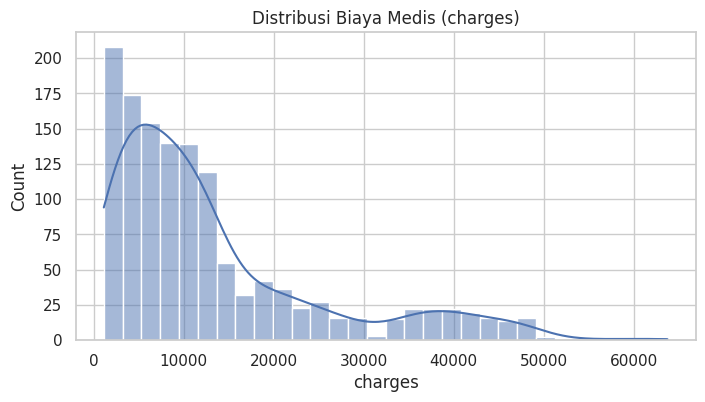

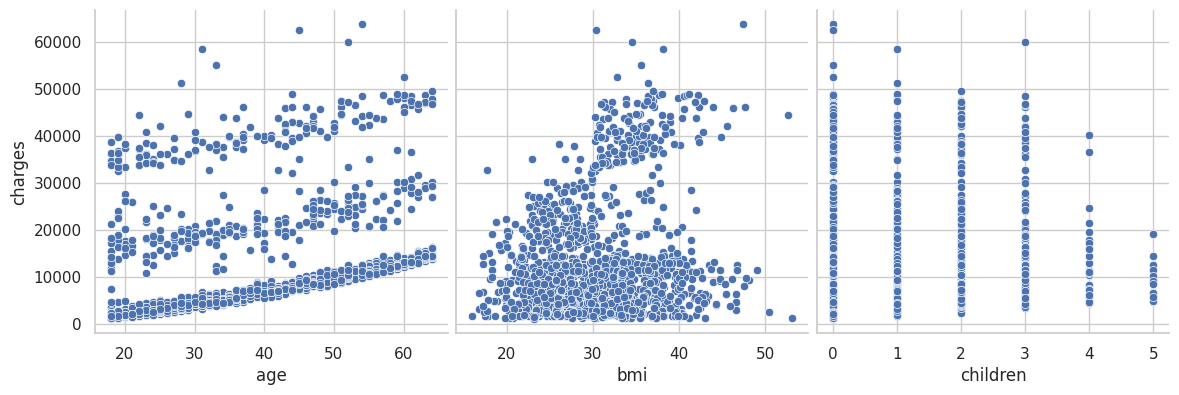

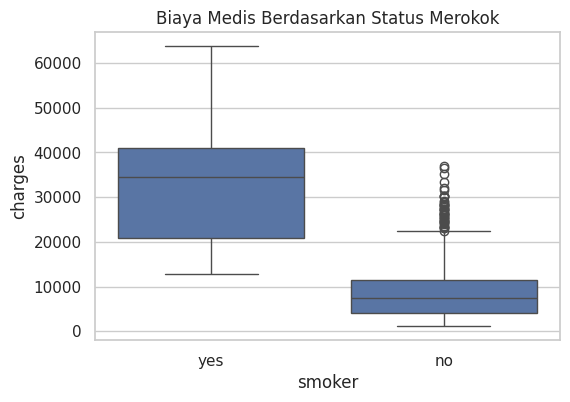

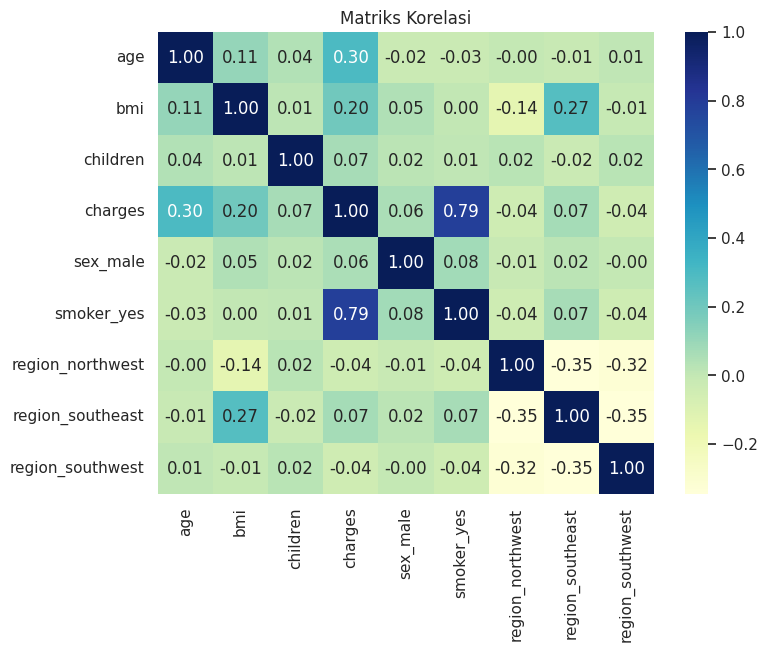

In [6]:
# Distribusi variabel target
plt.figure(figsize=(8, 4))
sns.histplot(data['charges'], bins=30, kde=True)
plt.title('Distribusi Biaya Medis (charges)')
plt.xlabel('charges')
plt.show()

# Hubungan variabel numerik dengan target
sns.pairplot(data, x_vars=['age', 'bmi', 'children'],
             y_vars='charges', height=4, aspect=1, kind='scatter')
plt.show()

# Pengaruh status merokok terhadap biaya
plt.figure(figsize=(6, 4))
sns.boxplot(x='smoker', y='charges', data=data)
plt.title('Biaya Medis Berdasarkan Status Merokok')
plt.show()

# Heatmap korelasi (hanya kolom numerik)
plt.figure(figsize=(8, 6))
sns.heatmap(data_encoded.corr(numeric_only=True), cmap="YlGnBu", annot=True, fmt=".2f")
plt.title('Matriks Korelasi')
plt.show()

# CATATAN EDA (contoh analisis, sesuaikan dengan hasil di lingkunganmu):
- Status "smoker" biasanya berkorelasi sangat kuat dengan charges: perokok
punya biaya medis jauh lebih tinggi daripada non-perokok.- "age" dan "bmi" juga berkorelasi positif dengan charges, meskipun
tidak sekuat "smoker".
- "children", "sex", dan "region" cenderung berkorelasi lemah dengan charges.

# **Tugas 1 - Identifikasi Variabel Bebas dan Target**
Variabel bebas (fitur)  : age, bmi, children, sex, smoker, region (setelah encoding)
Variabel target          : charges

In [7]:
X = data_encoded.drop('charges', axis=1)
y = data_encoded['charges']

print("Fitur (X):", X.columns.tolist())
print("Target (y): charges")

Fitur (X): ['age', 'bmi', 'children', 'sex_male', 'smoker_yes', 'region_northwest', 'region_southeast', 'region_southwest']
Target (y): charges


## **Tugas 2 - Split Data Latih dan Data Uji**

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Jumlah data latih:", X_train.shape[0])
print("Jumlah data uji  :", X_test.shape[0])

Jumlah data latih: 1070
Jumlah data uji  : 268


#Tugas 3 - Feature Scaling
Multiple Linear Regression sebenarnya tidak wajib di-scaling,
tapi SVR SANGAT sensitif terhadap skala data, jadi kita scaling semua fitur
numerik dan juga target agar konsisten dipakai untuk kedua model.

In [9]:
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

#Tugas 4 & 5 - Multiple Linear Regression

In [10]:
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)  # regresi linear pakai data asli (tanpa scaling)

y_pred_lr = lin_reg.predict(X_test)

print("Koefisien tiap fitur:")
for fitur, koef in zip(X.columns, lin_reg.coef_):
    print(f"  {fitur}: {koef:.2f}")
print("Intercept:", lin_reg.intercept_)

Koefisien tiap fitur:
  age: 256.98
  bmi: 337.09
  children: 425.28
  sex_male: -18.59
  smoker_yes: 23651.13
  region_northwest: -370.68
  region_southeast: -657.86
  region_southwest: -809.80
Intercept: -11931.21905032666


# Tugas 6 - Evaluasi Multiple Linear Regression

In [11]:
mae_lr = mean_absolute_error(y_test, y_pred_lr)
mse_lr = mean_squared_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print("=== Evaluasi Multiple Linear Regression ===")
print(f"MAE  : {mae_lr:.2f}")
print(f"MSE  : {mse_lr:.2f}")
print(f"RMSE : {rmse_lr:.2f}")
print(f"R2   : {r2_lr:.4f}")

=== Evaluasi Multiple Linear Regression ===
MAE  : 4181.19
MSE  : 33596915.85
RMSE : 5796.28
R2   : 0.7836


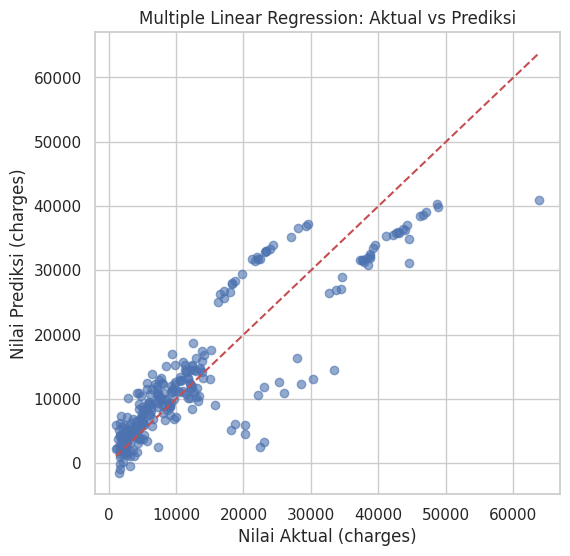

In [12]:
# Visualisasi Aktual vs Prediksi
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred_lr, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Nilai Aktual (charges)')
plt.ylabel('Nilai Prediksi (charges)')
plt.title('Multiple Linear Regression: Aktual vs Prediksi')
plt.show()

# Tugas 7 - Model SVR (dengan Feature Scaling)
SVR butuh y juga di-scaling

In [13]:
scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).ravel()

svr_reg = SVR(kernel='rbf')
svr_reg.fit(X_train_scaled, y_train_scaled)

y_pred_svr_scaled = svr_reg.predict(X_test_scaled)
y_pred_svr = scaler_y.inverse_transform(y_pred_svr_scaled.reshape(-1, 1)).ravel()

mae_svr = mean_absolute_error(y_test, y_pred_svr)
mse_svr = mean_squared_error(y_test, y_pred_svr)
rmse_svr = np.sqrt(mse_svr)
r2_svr = r2_score(y_test, y_pred_svr)

print("=== Evaluasi SVR (default, kernel='rbf') ===")
print(f"MAE  : {mae_svr:.2f}")
print(f"MSE  : {mse_svr:.2f}")
print(f"RMSE : {rmse_svr:.2f}")
print(f"R2   : {r2_svr:.4f}")

=== Evaluasi SVR (default, kernel='rbf') ===
MAE  : 2462.45
MSE  : 21380312.05
RMSE : 4623.88
R2   : 0.8623


In [15]:
#Hyperparameter Tuning SVR dengan GridSearchCV
param_grid = {
    'kernel': ['rbf'],
    'C': [1, 10, 100, 1000],
    'gamma': ['scale', 0.01, 0.1, 1],
    'epsilon': [0.01, 0.1, 0.5]
}

grid_search = GridSearchCV(
    SVR(), param_grid, cv=5,
    scoring='r2', n_jobs=-1, verbose=1
)
grid_search.fit(X_train_scaled, y_train_scaled)

print("Parameter terbaik:", grid_search.best_params_)
print("Best CV R2 score  :", grid_search.best_score_)

best_svr = grid_search.best_estimator_
y_pred_best_svr_scaled = best_svr.predict(X_test_scaled)
y_pred_best_svr = scaler_y.inverse_transform(y_pred_best_svr_scaled.reshape(-1, 1)).ravel()

mae_best = mean_absolute_error(y_test, y_pred_best_svr)
mse_best = mean_squared_error(y_test, y_pred_best_svr)
rmse_best = np.sqrt(mse_best)
r2_best = r2_score(y_test, y_pred_best_svr)

print("=== Evaluasi SVR (setelah hyperparameter tuning) ===")
print(f"MAE  : {mae_best:.2f}")
print(f"MSE  : {mse_best:.2f}")
print(f"RMSE : {rmse_best:.2f}")
print(f"R2   : {r2_best:.4f}")

Fitting 5 folds for each of 48 candidates, totalling 240 fits
Parameter terbaik: {'C': 100, 'epsilon': 0.1, 'gamma': 0.01, 'kernel': 'rbf'}
Best CV R2 score  : 0.8321022153786286
=== Evaluasi SVR (setelah hyperparameter tuning) ===
MAE  : 2417.03
MSE  : 20345260.11
RMSE : 4510.57
R2   : 0.8690


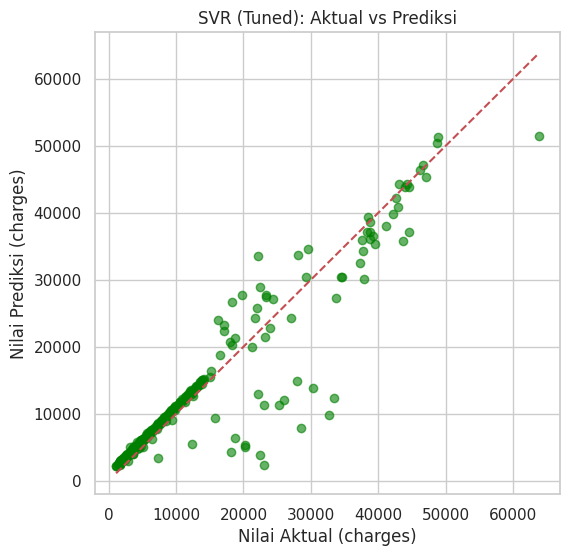

In [16]:
# Visualisasi Aktual vs Prediksi (SVR terbaik)
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred_best_svr, alpha=0.6, color='green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Nilai Aktual (charges)')
plt.ylabel('Nilai Prediksi (charges)')
plt.title('SVR (Tuned): Aktual vs Prediksi')
plt.show()

In [17]:
# Perbandingan Akhir Model
hasil = pd.DataFrame({
    'Model': ['Multiple Linear Regression', 'SVR (default)', 'SVR (tuned)'],
    'MAE': [mae_lr, mae_svr, mae_best],
    'MSE': [mse_lr, mse_svr, mse_best],
    'RMSE': [rmse_lr, rmse_svr, rmse_best],
    'R2': [r2_lr, r2_svr, r2_best]
})
print(hasil)

                        Model          MAE           MSE         RMSE  \
0  Multiple Linear Regression  4181.194474  3.359692e+07  5796.284659   
1               SVR (default)  2462.452730  2.138031e+07  4623.884952   
2                 SVR (tuned)  2417.026096  2.034526e+07  4510.572038   

         R2  
0  0.783593  
1  0.862283  
2  0.868951  


## Analisis Hasil Praktikum

### Ringkasan Dataset
Dataset "Medical Cost Personal Datasets" terdiri dari 1338 baris data dan 7 kolom
(age, sex, bmi, children, smoker, region, charges), tanpa ada missing value.
Setelah dilakukan encoding pada kolom kategorik (sex, smoker, region), diperoleh
8 fitur yang digunakan untuk memprediksi variabel target charges (biaya medis).

### Analisis Koefisien Multiple Linear Regression
Berdasarkan koefisien regresi, status merokok (smoker_yes) merupakan faktor
paling dominan dalam menentukan biaya medis, dengan koefisien sebesar 23651.13,
jauh lebih besar dibandingkan fitur lain seperti age (256.98), bmi (337.09),
dan children (425.28). Hal ini sesuai dengan fakta bahwa kebiasaan merokok
merupakan faktor risiko kesehatan yang signifikan dan berdampak besar pada
biaya asuransi kesehatan. Sementara itu, fitur wilayah (region) memiliki
koefisien negatif kecil, menunjukkan pengaruh yang relatif lemah terhadap
biaya medis.

### Perbandingan Performa Model

| Model                        | MAE     | RMSE    | R²     |
|-------------------------------|---------|---------|--------|
| Multiple Linear Regression    | 4181.19 | 5796.28 | 0.7836 |
| SVR (default, kernel RBF)     | 2462.45 | 4623.88 | 0.8623 |
| SVR (tuned)                   | 2417.03 | 4510.57 | 0.8690 |

Hasil evaluasi menunjukkan bahwa model SVR secara konsisten mengungguli
Multiple Linear Regression, baik dari sisi error (MAE dan RMSE yang lebih
rendah) maupun kemampuan menjelaskan variasi data (R² yang lebih tinggi).
R² meningkat dari 0.7836 pada Linear Regression menjadi 0.8623 pada SVR
default, dan sedikit meningkat lagi menjadi 0.8690 setelah dilakukan
hyperparameter tuning menggunakan GridSearchCV.

Peningkatan performa pada SVR ini mengindikasikan bahwa hubungan antara
fitur (khususnya age, bmi, dan smoker) dengan charges bersifat non-linear,
sehingga kernel RBF pada SVR mampu menangkap pola tersebut lebih baik
dibandingkan model linear.

### Hasil Hyperparameter Tuning
Melalui GridSearchCV dengan 5-fold cross-validation, diperoleh kombinasi
parameter terbaik yaitu C=100, epsilon=0.1, dan gamma=0.01, dengan skor
R² cross-validation sebesar 0.8321. Peningkatan performa setelah tuning
tergolong kecil dibandingkan model SVR default, yang menunjukkan bahwa
parameter default SVR sudah cukup mendekati konfigurasi optimal untuk
dataset ini.

### Kesimpulan
Model SVR dengan kernel RBF, khususnya setelah dilakukan hyperparameter
tuning, terbukti menjadi model terbaik untuk memprediksi biaya medis
personal pada dataset ini. Model ini mampu menangkap hubungan non-linear
antar variabel, terutama peran dominan status merokok yang berinteraksi
dengan faktor usia dan BMI, sehingga menghasilkan prediksi yang lebih
akurat dibandingkan Multiple Linear Regression. Meskipun begitu, R² sebesar
0.869 menunjukkan masih ada sekitar 13% variasi data yang belum dapat
dijelaskan oleh model, kemungkinan disebabkan oleh adanya outlier pada
kasus biaya medis yang sangat tinggi serta faktor-faktor lain yang tidak
tercakup dalam dataset.